# DL070 可执行实验

代码单元按序真实运行，输出保存在notebook_outputs。

In [1]:
from pathlib import Path
import sys,json,numpy as np,torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image,display
def show(fig):
    b=BytesIO();fig.savefig(b,format='png',dpi=140,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'device': 'CPU'}


## 先读取固定计划

In [2]:
print(json.dumps(e.PLAN,ensure_ascii=False,indent=2))

{
  "task": "synthetic nonlinear binary classification",
  "data_seed": 7001,
  "train_n": 128,
  "validation_n": 192,
  "test_n": 512,
  "seeds": [
    11,
    23,
    37,
    51,
    67
  ],
  "epochs": 160,
  "optimizer": "Adam",
  "lr": 0.01,
  "modes": {
    "baseline": [
      0.0,
      0.0
    ],
    "dropout": [
      0.4,
      0.0
    ],
    "weight_decay": [
      0.0,
      0.01
    ],
    "both": [
      0.4,
      0.01
    ]
  },
  "selection": "minimum validation NLL; earliest tie",
  "primary": "paired test NLL difference dropout - baseline; negative is better",
  "secondary": "accuracy, calibration, factorial interaction",
  "hypothesis": "dropout may reduce overfitting at this fixed capacity and budget",
  "scope": "mechanism-scale reproduction, not original paper benchmark scores"
}


## 运行配对初始化与数学测试

In [3]:
import unittest,test_experiment
z=unittest.TextTestRunner().run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not z.wasSuccessful():raise RuntimeError('tests failed')

.

.

.

.

.

----------------------------------------------------------------------
Ran 5 tests in 0.443s

OK


## 实际执行20个训练分支

In [4]:
r=e.run("notebook_outputs");print(r["summary"]);print(r["paired_dropout_minus_baseline"]);print(r["budget"])

{'baseline': {'nll': 0.6434467911720276, 'accuracy': 0.614453125, 'brier': 0.2261028289794922}, 'dropout': {'nll': 0.6283358573913574, 'accuracy': 0.65078125, 'brier': 0.2181580811738968}, 'weight_decay': {'nll': 0.6381996870040894, 'accuracy': 0.672265625, 'brier': 0.21144409477710724}, 'both': {'nll': 0.6213859438896179, 'accuracy': 0.65546875, 'brier': 0.21571333408355714}}
{'values': [-0.0013448596000671387, -0.042604267597198486, -0.012639105319976807, -0.005789518356323242, -0.013176918029785156], 'mean': -0.015110933780670166, 'sample_sd': 0.01614099858334315, 'standard_error': 0.007218474011416618, 'ci95': [-0.03515263061666531, 0.004930763055324984], 'interpretation': 'approximate t interval over initialization seeds, conditional on one fixed dataset'}
{'runs': 20, 'updates_per_run': 160, 'total_updates': 3200, 'train_examples_per_update': 128, 'train_seconds': 3.4785533050016966}


## 配对差来自每个种子

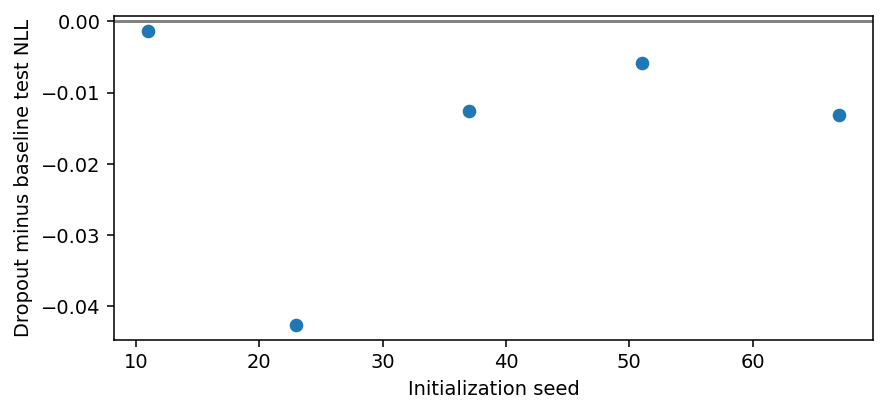

In [5]:
d=r["paired_dropout_minus_baseline"];fig,ax=plt.subplots(figsize=(7,3));ax.scatter(e.SEEDS,d["values"]);ax.axhline(0,color="gray");ax.set(xlabel="Initialization seed",ylabel="Dropout minus baseline test NLL");show(fig)

## 所有checkpoint重载检查

In [6]:
x,y=e.data()
for row in r["runs"]:
    ck=torch.load(f"notebook_outputs/{row['mode']}_seed{row['seed']}.pt",weights_only=True);m=e.model(ck["p"]);m.load_state_dict(ck["state_dict"]);z=e.evaluate(m,x[320:],y[320:])
    np.testing.assert_allclose(z["nll"],row["test"]["nll"],rtol=0,atol=1e-7)
print("20 checkpoints independently reloaded")

20 checkpoints independently reloaded


## 看见选择规则与限制

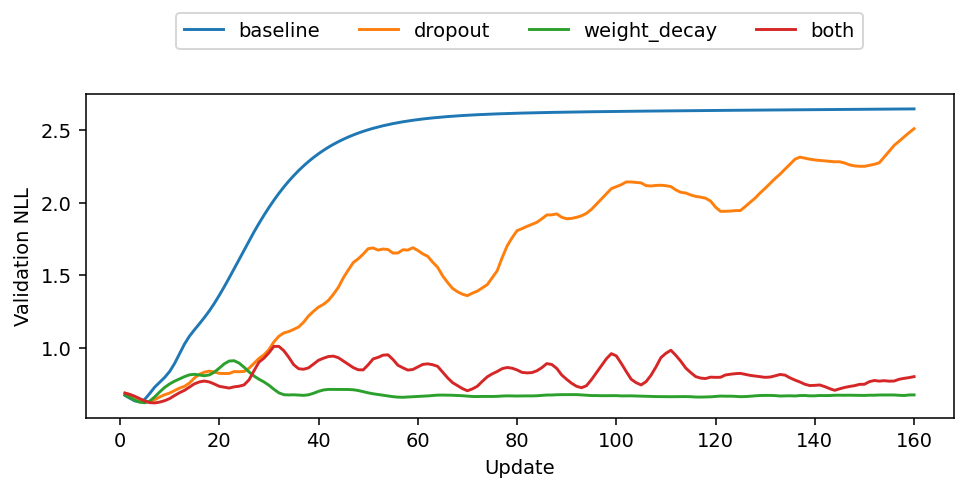

['One synthetic dataset, five initialization seeds, no original vision/speech/document benchmarks', 'No hyperparameter search; fixed dropout rate and weight decay', 'Seed interval excludes dataset and deployment distribution uncertainty', 'Validation-selected epochs differ despite equal maximum training budgets']


In [7]:
fig,ax=plt.subplots(figsize=(8,3))
for mode in e.MODES:
    row=next(a for a in r["runs"] if a["seed"]==11 and a["mode"]==mode);ax.plot([h["epoch"] for h in row["history"]],[h["validation_nll"] for h in row["history"]],label=mode)
ax.set(xlabel="Update",ylabel="Validation NLL");ax.legend(loc="upper center",bbox_to_anchor=(0.5,1.28),ncol=4);show(fig)
print(r["limits"])